
# Clasificación Iris (Setosa vs Versicolor) — Confusion Matrix & Métricas

Este notebook **usa** 10 observaciones con atributos de la flor Iris y predicciones para ilustrar la **matriz de confusión** y las métricas:  
**Accuracy, Precision, Recall, F1-score**.  

Se considera:  
**- Setosa = clase positiva (1)**  
**- Versicolor = clase negativa (0)**.


Importar librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

## 1) Cargar datos

In [13]:
# Datos provistos (10 filas) — incluyen FP y FN deliberadamente
data = [
    # ID, SepalLength, SepalWidth, PetalLength, PetalWidth, Real, Pred
    [1, 5.1, 3.5, 1.4, 0.2, "Setosa",      "Setosa"     ],
    [2, 6.0, 2.9, 4.5, 1.5, "Versicolor",  "Versicolor" ],
    [3, 5.5, 2.4, 3.8, 1.1, "Versicolor",  "Setosa"     ],  # FP
    [4, 4.9, 3.1, 1.5, 0.1, "Setosa",      "Setosa"     ],
    [5, 6.2, 2.8, 4.8, 1.8, "Versicolor",  "Versicolor" ],
    [6, 5.7, 2.8, 4.1, 1.3, "Versicolor",  "Versicolor" ],
    [7, 4.8, 3.0, 1.4, 0.2, "Setosa",      "Versicolor" ],  # FN
    [8, 5.4, 3.9, 1.7, 0.4, "Setosa",      "Setosa"     ],
    [9, 6.3, 2.5, 4.9, 1.5, "Versicolor",  "Versicolor" ],
    [10,5.0, 3.4, 1.6, 0.2, "Setosa",      "Setosa"     ],
]

cols = ["ID","SepalLength","SepalWidth","PetalLength","PetalWidth","Etiqueta real (Especie)","Predicción del modelo"]
df = pd.DataFrame(data, columns=cols)

# Mapear a 1/0 (Setosa=1, Versicolor=0)
y_true = (df["Etiqueta real (Especie)"] == "Setosa").astype(int).values
y_pred = (df["Predicción del modelo"] == "Setosa").astype(int).values

df

,ID,SepalLength,SepalWidth,PetalLength,PetalWidth,Etiqueta real (Especie),Predicción del modelo
0,1,5.1,3.5,1.4,0.2,Setosa,Setosa
1,2,6.0,2.9,4.5,1.5,Versicolor,Versicolor
2,3,5.5,2.4,3.8,1.1,Versicolor,Setosa
3,4,4.9,3.1,1.5,0.1,Setosa,Setosa
4,5,6.2,2.8,4.8,1.8,Versicolor,Versicolor
5,6,5.7,2.8,4.1,1.3,Versicolor,Versicolor
6,7,4.8,3.0,1.4,0.2,Setosa,Versicolor
7,8,5.4,3.9,1.7,0.4,Setosa,Setosa
8,9,6.3,2.5,4.9,1.5,Versicolor,Versicolor
9,10,5.0,3.4,1.6,0.2,Setosa,Setosa


## 2) Matriz de confusión

In [2]:

# Orden: filas = reales [1,0], columnas = predichos [1,0]
labels = [1,0]
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm

array([[4, 1],
       [1, 4]])


Visualización


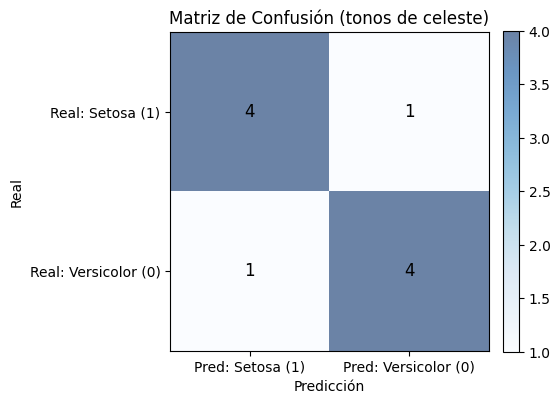

In [12]:

fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(cm, cmap="Blues", alpha=0.6)

ax.set_xticks([0,1]); ax.set_xticklabels(['Pred: Setosa (1)','Pred: Versicolor (0)'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Real: Setosa (1)','Real: Versicolor (0)'])

# Mostrar los valores dentro de cada celda en color negro para contraste
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=12)

ax.set_title('Matriz de Confusión (tonos de celeste)')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()


## 3) Métricas (clase positiva = Setosa)

In [4]:

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1)
rec = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred, target_names=['versicolor (0)','setosa (1)']))


Accuracy : 0.800
Precision: 0.800
Recall   : 0.800
F1-score : 0.800

Reporte de clasificación:

                precision    recall  f1-score   support

versicolor (0)       0.80      0.80      0.80         5
    setosa (1)       0.80      0.80      0.80         5

      accuracy                           0.80        10
     macro avg       0.80      0.80      0.80        10
  weighted avg       0.80      0.80      0.80        10




## 4) Cálculo manual de TP, TN, FP, FN y verificación
Con el orden de etiquetas `[1, 0]`:
- `TP = cm[0,0]`, `FN = cm[0,1]`
- `FP = cm[1,0]`, `TN = cm[1,1]`


In [5]:

TP = cm[0,0]; FN = cm[0,1]; FP = cm[1,0]; TN = cm[1,1]
acc_m = (TP + TN) / (TP + TN + FP + FN)
prec_m = TP / (TP + FP) if (TP + FP) else 0.0
rec_m  = TP / (TP + FN) if (TP + FN) else 0.0
f1_m   = 2 * (prec_m * rec_m) / (prec_m + rec_m) if (prec_m + rec_m) else 0.0

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Accuracy (manual) : {acc_m:.3f}")
print(f"Precision (manual): {prec_m:.3f}")
print(f"Recall (manual)   : {rec_m:.3f}")
print(f"F1-score (manual) : {f1_m:.3f}")


TP=4, TN=4, FP=1, FN=1
Accuracy (manual) : 0.800
Precision (manual): 0.800
Recall (manual)   : 0.800
F1-score (manual) : 0.800



## 5) Actividades sugeridas
1. Cambia la **clase positiva** a Versicolor (0) y recalcula métricas.
2. Modifica una o dos filas de **Predicción del modelo** y observa cómo cambia la matriz y las métricas.
3. Agrega más filas al `DataFrame` con nuevos casos reales/predichos para ver distintos escenarios.
